* Name: Mustaqueem Alam <br>
* ID  : 2621752 <br>
* ID Serial: 43 <br>
* Course Title : Image Processing <br>
* Course Code : CSC604/CSE420 <br>
* Section :02 <br>

## PROJECT SETUP & LIBRARY IMPORTS

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mount Google Drive
drive.mount('/content/drive')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive


## PATHS & CONFIGURATION

In [2]:
project_path     = '/content/drive/MyDrive/CSE420'
dataset_path     = os.path.join(project_path, 'Ultrasound Fetus Dataset_Classification')
prep_prewitt_dir = os.path.join(project_path, 'preprocessing_prewitt')
os.makedirs(project_path, exist_ok=True)

BATCH_SIZE  = 32
IMG_SIZE    = (224, 224)
EPOCHS_TL   = 25
EPOCHS_FT   = 15
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'malignant', 'normal']
splits      = ['train', 'test', 'validation']
SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## DATA EXPLORATION & CLASS DISTRIBUTION (RAW DATASET)


--- Scanning Raw Dataset ---

--- Dataset Summary ---
     Split     Class  Count
     train    benign    241
     train malignant    729
     train    normal    242
      test    benign     51
      test malignant    148
      test    normal     50
validation    benign     43
validation malignant    122
validation    normal     43

Total images: 1669


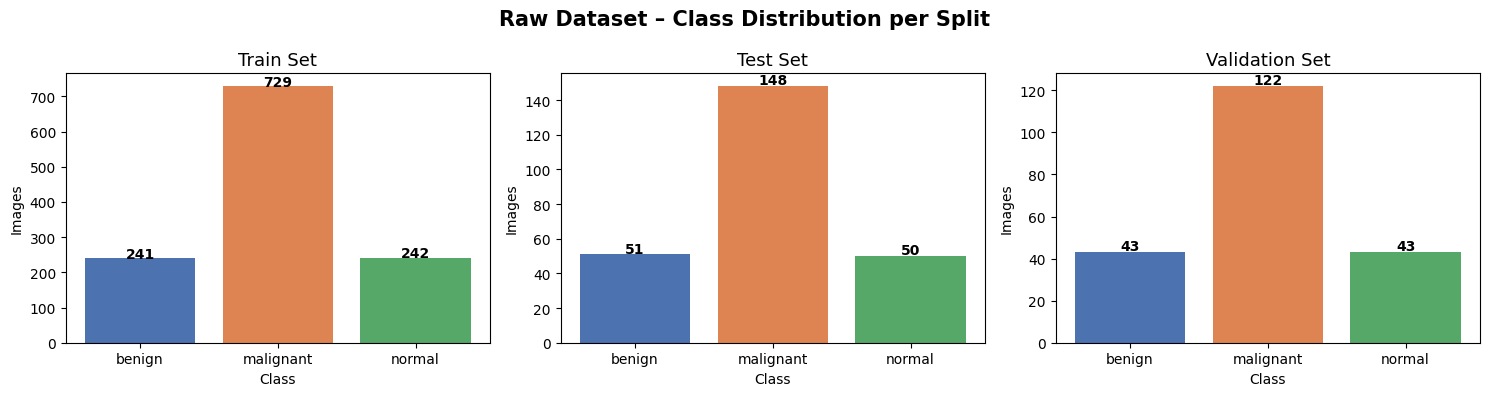

In [3]:
data_info = []
print("\n--- Scanning Raw Dataset ---")
for split in splits:
    split_dir = os.path.join(dataset_path, split)
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.exists(cls_path):
            imgs = [p for p in glob.glob(os.path.join(cls_path, '*.*'))
                    if 'Annotation' not in os.path.basename(p)]
            data_info.append({'Split': split, 'Class': cls, 'Count': len(imgs)})
        else:
            print(f"  Warning – not found: {cls_path}")

df_stats = pd.DataFrame(data_info)
print("\n--- Dataset Summary ---")
print(df_stats.to_string(index=False))
print(f"\nTotal images: {df_stats['Count'].sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, split in zip(axes, splits):
    sub = df_stats[df_stats['Split'] == split]
    bars = ax.bar(sub['Class'], sub['Count'], color=colors)
    ax.set_title(f'{split.capitalize()} Set', fontsize=13)
    ax.set_xlabel('Class'); ax.set_ylabel('Images')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=10)
plt.suptitle('Raw Dataset – Class Distribution per Split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## PREWITT PREPROCESSING – APPLY & SAVE TO DRIVE

In [4]:
for split in splits:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(prep_prewitt_dir, split, cls), exist_ok=True)

print(f"\n--- Preprocessing Directories Created ---")
print(f"Base Output: {prep_prewitt_dir}")


def preprocess_prewitt(image, target_size=224):
    """Apply Prewitt edge detection + black square padding."""

    if image is None:
        return None

    # --- Prewitt edge detection ---
    kernelx = np.array([[1,  1,  1],
                        [0,  0,  0],
                        [-1, -1, -1]], dtype=np.float32)
    kernely = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=np.float32)

    img_prewittx = cv2.filter2D(image, cv2.CV_32F, kernelx)
    img_prewitty = cv2.filter2D(image, cv2.CV_32F, kernely)
    prewitt_mag  = cv2.magnitude(img_prewittx, img_prewitty)

    img_prewitt = cv2.normalize(
        prewitt_mag, None, 0, 255,
        cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )

    # --- Convert grayscale → RGB (IMPORTANT for ResNet50) ---
    img_prewitt = cv2.cvtColor(img_prewitt, cv2.COLOR_GRAY2RGB)

    # --- Get original size ---
    h, w = img_prewitt.shape[:2]

    # --- Scale while preserving aspect ratio ---
    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    img_resized = cv2.resize(img_prewitt, (new_w, new_h))

    # --- Create black square canvas ---
    padded = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    # --- Center the image ---
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

    return padded


print("\n--- Applying Prewitt Filter & Saving Preprocessed Images ---")
for split in splits:
    split_dir = os.path.join(dataset_path, split)
    if not os.path.exists(split_dir):
        continue
    print(f"  Processing split: {split} ...")
    for cls in CLASS_NAMES:
        input_cls_path = os.path.join(split_dir, cls)
        if not os.path.exists(input_cls_path):
            continue
        img_paths = [p for p in glob.glob(os.path.join(input_cls_path, '*.*'))
                     if 'Annotation' not in os.path.basename(p)]
        for img_path in img_paths:
            img_name    = os.path.basename(img_path)
            raw_img     = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if raw_img is None:
                continue
            prewitt_img = preprocess_prewitt(raw_img)
            out_path    = os.path.join(prep_prewitt_dir, split, cls, img_name)
            cv2.imwrite(out_path, prewitt_img)

print("\nPreprocessing complete! Images saved to Drive at:")
print(f"  {prep_prewitt_dir}")


--- Preprocessing Directories Created ---
Base Output: /content/drive/MyDrive/CSE420/preprocessing_prewitt

--- Applying Prewitt Filter & Saving Preprocessed Images ---
  Processing split: train ...
  Processing split: test ...
  Processing split: validation ...

Preprocessing complete! Images saved to Drive at:
  /content/drive/MyDrive/CSE420/preprocessing_prewitt


## VISUALISE RAW vs PREWITT SAMPLES

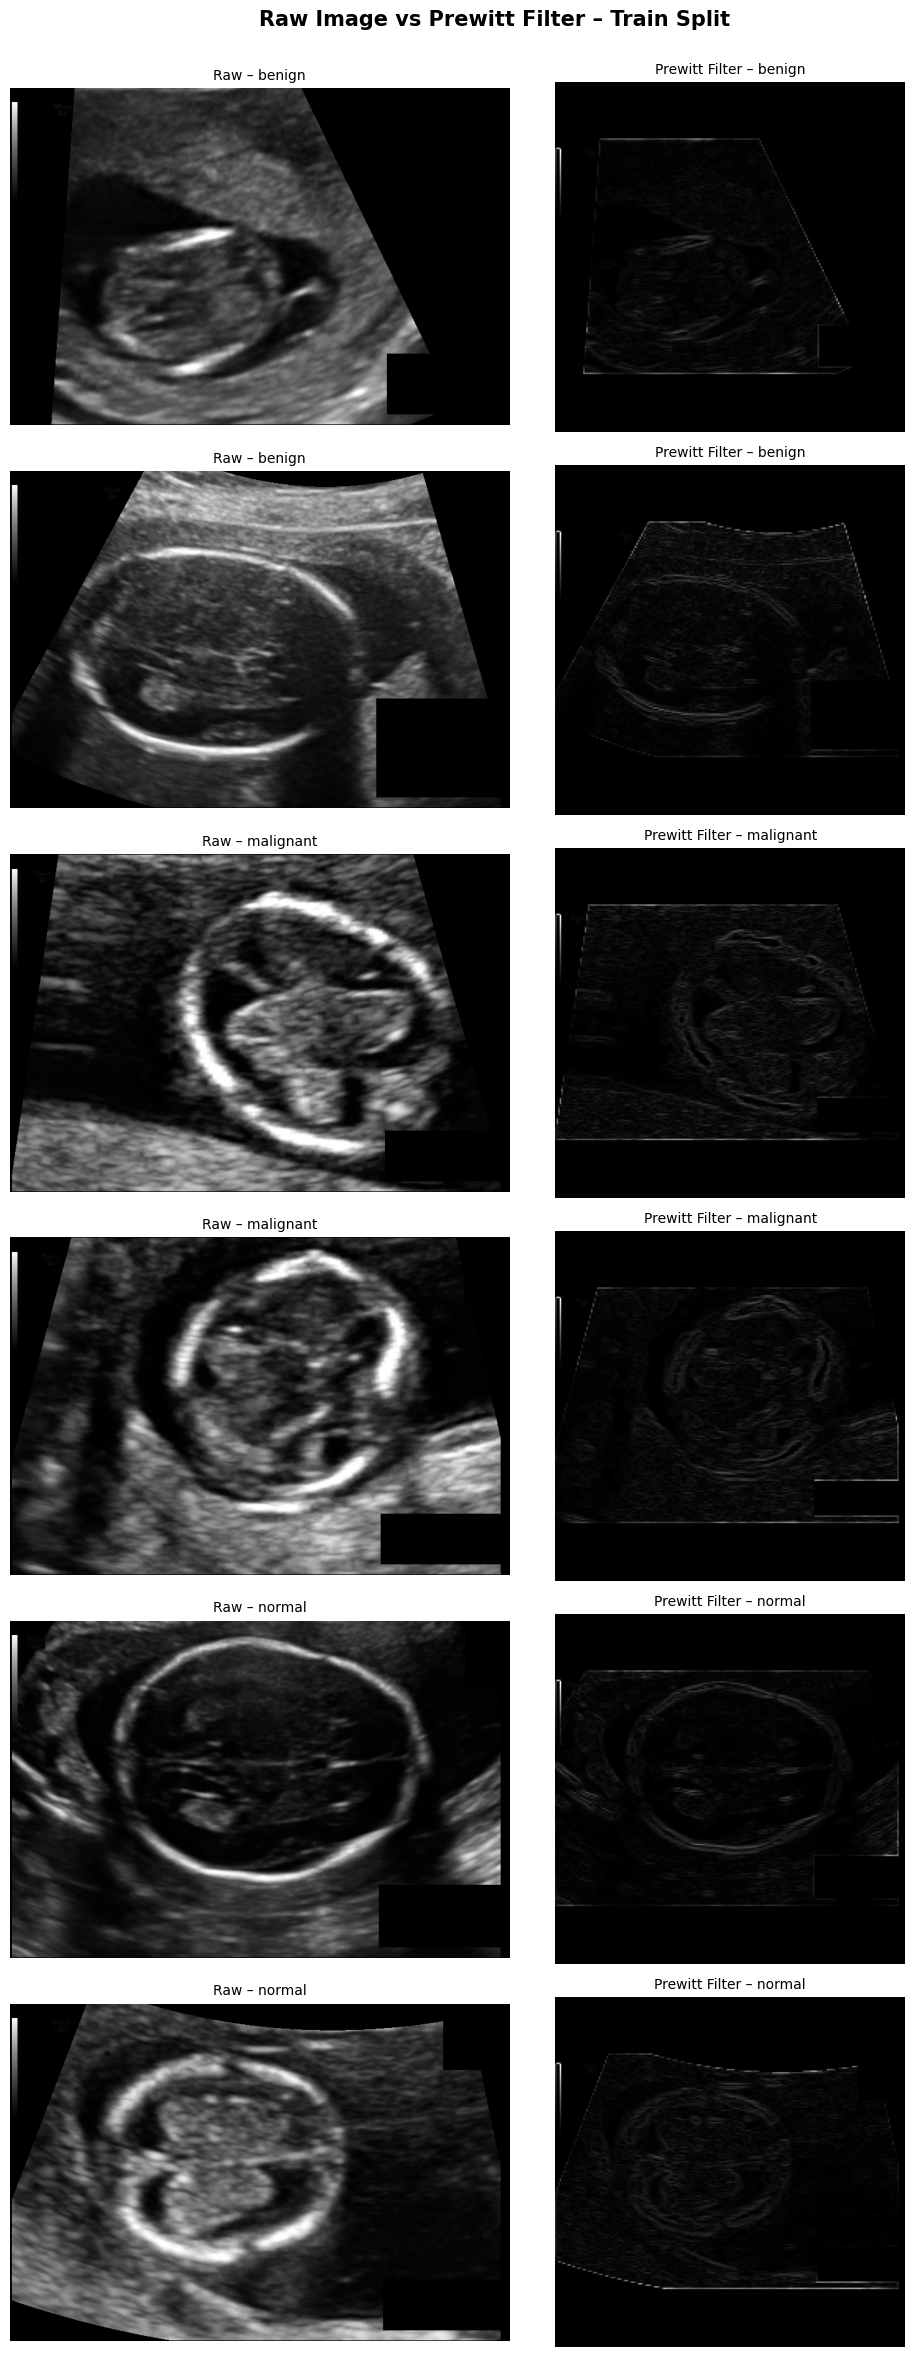

In [5]:
def plot_raw_vs_prewitt(classes, target_split='train', num_samples=2):
    n_rows = len(classes) * num_samples
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
    fig.suptitle(
        f'Raw Image vs Prewitt Filter – {target_split.capitalize()} Split',
        fontsize=15, fontweight='bold')
    if n_rows == 1:
        axes = np.array([axes])
    row = 0
    for cls in classes:
        prewitt_cls_dir = os.path.join(prep_prewitt_dir, target_split, cls)
        prewitt_paths   = glob.glob(os.path.join(prewitt_cls_dir, '*.*'))[:num_samples]
        for p_path in prewitt_paths:
            img_name = os.path.basename(p_path)
            raw_path = os.path.join(dataset_path, target_split, cls, img_name)
            raw_img     = cv2.imread(raw_path, cv2.IMREAD_GRAYSCALE)
            prewitt_img = cv2.imread(p_path,   cv2.IMREAD_GRAYSCALE)
            if raw_img is None or prewitt_img is None:
                continue
            axes[row, 0].imshow(raw_img,     cmap='gray')
            axes[row, 0].set_title(f'Raw – {cls}',            fontsize=10)
            axes[row, 0].axis('off')
            axes[row, 1].imshow(prewitt_img, cmap='gray')
            axes[row, 1].set_title(f'Prewitt Filter – {cls}', fontsize=10)
            axes[row, 1].axis('off')
            row += 1
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

plot_raw_vs_prewitt(CLASS_NAMES, target_split='train', num_samples=2)

## LOAD PREPROCESSED DATASETS FOR TRAINING

In [6]:
print("\n--- Loading Prewitt-Preprocessed Datasets ---")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prep_prewitt_dir, 'train'),
    label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
    color_mode='grayscale') # Added: Load as grayscale

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prep_prewitt_dir, 'validation'),
    label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
    color_mode='grayscale') # Added: Load as grayscale

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prep_prewitt_dir, 'test'),
    label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
    color_mode='grayscale') # Added: Load as grayscale

class_names = train_ds.class_names
print(f"Class names (auto-detected): {class_names}")


def preprocess_for_resnet(image, label):
    """Convert grayscale→3ch if needed, then apply ResNet50 preprocessing."""
    image = tf.cond(
        tf.equal(tf.shape(image)[-1], 1),
        lambda: tf.image.grayscale_to_rgb(image),
        lambda: image)
    return preprocess_input(image), label


train_ds_pp = train_ds.map(preprocess_for_resnet).prefetch(tf.data.AUTOTUNE)
val_ds_pp   = val_ds.map(preprocess_for_resnet).prefetch(tf.data.AUTOTUNE)
test_ds_pp  = test_ds.map(preprocess_for_resnet).prefetch(tf.data.AUTOTUNE)


--- Loading Prewitt-Preprocessed Datasets ---
Found 1212 files belonging to 3 classes.
Found 208 files belonging to 3 classes.
Found 249 files belonging to 3 classes.
Class names (auto-detected): ['benign', 'malignant', 'normal']


## MODEL ARCHITECTURE – PHASE 1 (FROZEN BASE)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

In [8]:
def build_model_phase1():
    """ResNet50 base frozen, custom classification head."""
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(*IMG_SIZE, 3))
    base.trainable = False   # Freeze entire base

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

model, base_model = build_model_phase1()
model.summary()
print(f"\nTrainable params (Phase 1): {model.trainable_variables.__len__()}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,868,611 (91.05 MB)

 Trainable params: 276,803 (1.06 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


Trainable params (Phase 1): 10


## TRAINING – PHASE 1 (TRANSFER LEARNING)

In [9]:
cb_early   = callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                      restore_best_weights=True, verbose=1)
cb_reduce  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                          patience=25, min_lr=1e-7, verbose=1)
cb_ckpt_p1 = callbacks.ModelCheckpoint(
    os.path.join(project_path, 'best_model_phase1.h5'),
    monitor='val_accuracy', save_best_only=True, verbose=1)

print("\n--- Phase 1: Transfer Learning (Frozen Base) ---")
history_p1 = model.fit(
    train_ds_pp, validation_data=val_ds_pp,
    epochs=EPOCHS_TL,
    callbacks=[cb_early, cb_reduce, cb_ckpt_p1],
    verbose=1
)


--- Phase 1: Transfer Learning (Frozen Base) ---
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5308 - loss: 1.3904
Epoch 1: val_accuracy improved from None to 0.45192, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 698ms/step - accuracy: 0.5099 - loss: 1.3600 - val_accuracy: 0.4519 - val_loss: 1.0944 - learning_rate: 0.0010
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.5106 - loss: 1.1710
Epoch 2: val_accuracy improved from 0.45192 to 0.51923, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step - accuracy: 0.5289 - loss: 1.1487 - val_accuracy: 0.5192 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5227 - loss: 1.0903
Epoch 3: val_accuracy improved from 0.51923 to 0.52404, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step - accuracy: 0.5487 - loss: 1.0854 - val_accuracy: 0.5240 - val_loss: 1.0542 - learning_rate: 0.0010
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5647 - loss: 1.0220
Epoch 4: val_accuracy improved from 0.52404 to 0.57692, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.5644 - loss: 1.0223 - val_accuracy: 0.5769 - val_loss: 1.0538 - learning_rate: 0.0010
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5932 - loss: 0.9502
Epoch 5: val_accuracy did not improve from 0.57692
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.5883 - loss: 0.9673 - val_accuracy: 0.5337 - val_loss: 1.0551 - learning_rate: 0.0010
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6104 - loss: 0.9441
Epoch 6: val_accuracy did not improve from 0.57692
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.5924 - loss: 0.9776 - val_accuracy: 0.5577 - val_loss: 1.0184 - learning_rate: 0.0010
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6022 - loss: 0.9550
Epoch 7: val_accuracy improved from 0.57692 to 0.58173, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 7: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 290ms/step - accuracy: 0.6007 - loss: 0.9462 - val_accuracy: 0.5817 - val_loss: 1.0139 - learning_rate: 0.0010
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6112 - loss: 0.9264
Epoch 8: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.6114 - loss: 0.9071 - val_accuracy: 0.5625 - val_loss: 1.0080 - learning_rate: 0.0010
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6427 - loss: 0.8904
Epoch 9: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.6238 - loss: 0.9164 - val_accuracy: 0.5625 - val_loss: 0.9838 - learning_rate: 0.0010
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6491 - loss: 0.8534
Epoch 10: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.6345 - loss: 0.8679 - 


Epoch 12: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.6617 - loss: 0.7919 - val_accuracy: 0.5865 - val_loss: 0.9494 - learning_rate: 0.0010
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6626 - loss: 0.7903
Epoch 13: val_accuracy did not improve from 0.58654
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.6617 - loss: 0.7824 - val_accuracy: 0.5673 - val_loss: 0.9376 - learning_rate: 0.0010
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6911 - loss: 0.7206
Epoch 14: val_accuracy did not improve from 0.58654
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.6741 - loss: 0.7569 - val_accuracy: 0.5769 - val_loss: 0.9386 - learning_rate: 0.0010
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6835 - loss: 0.7148
Epoch 15: val_accuracy did not improve from 0.58654
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.6741 - loss: 0.72

## EVALUATE PHASE 1 – CURVES, CONFUSION MATRIX, ROC-AUC

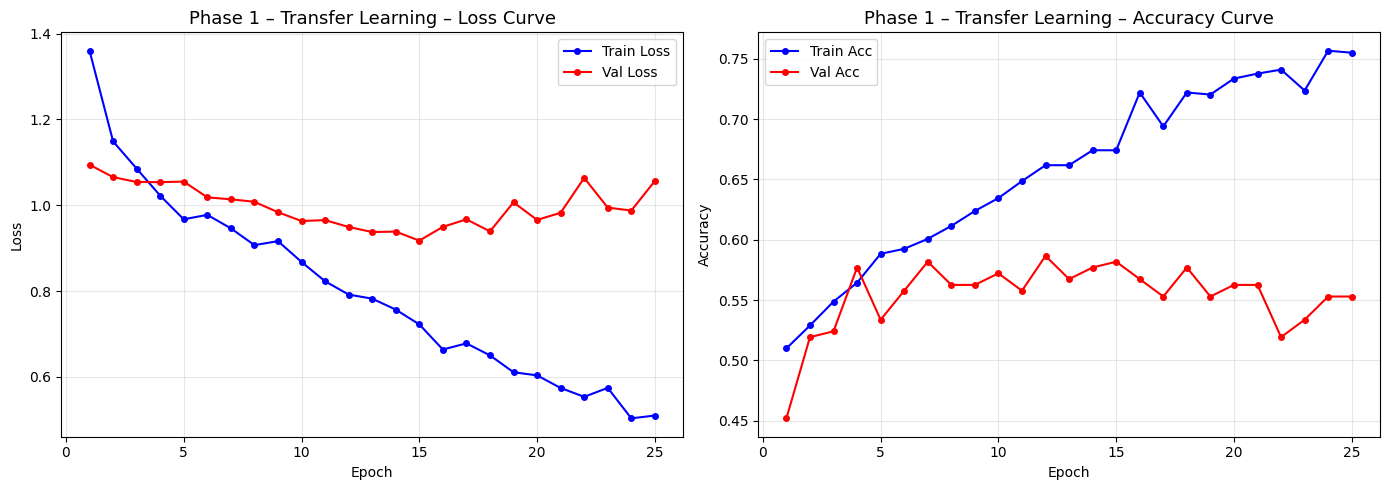


--- Phase 1 – Transfer Learning: Classification Report ---
              precision    recall  f1-score   support

      benign       0.26      0.20      0.22        51
   malignant       0.74      0.87      0.80       148
      normal       0.25      0.18      0.21        50

    accuracy                           0.59       249
   macro avg       0.42      0.42      0.41       249
weighted avg       0.54      0.59      0.56       249



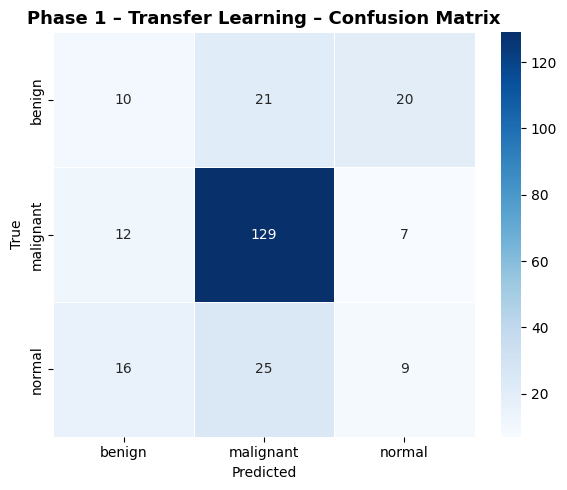

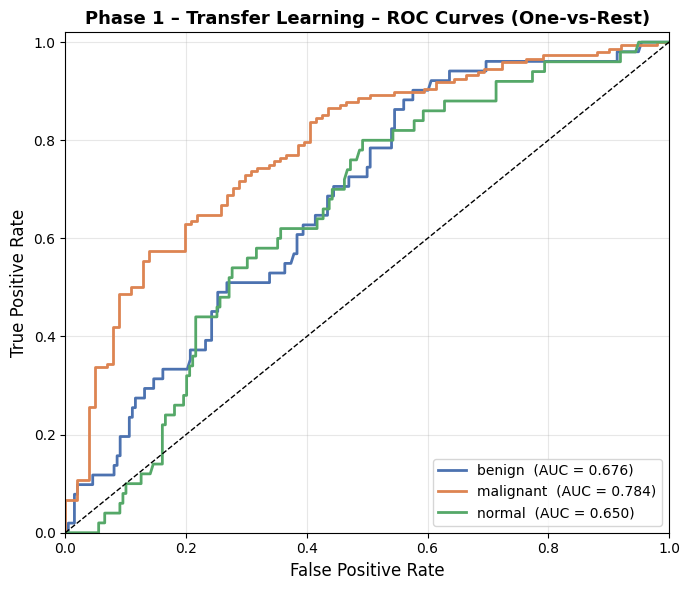

In [10]:
def plot_training_curves(history, title_prefix="Phase 1"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history.history['loss']) + 1)

    axes[0].plot(ep, history.history['loss'],     'b-o', label='Train Loss', markersize=4)
    axes[0].plot(ep, history.history['val_loss'], 'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title(f'{title_prefix} – Loss Curve', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, history.history['accuracy'],     'b-o', label='Train Acc', markersize=4)
    axes[1].plot(ep, history.history['val_accuracy'], 'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title(f'{title_prefix} – Accuracy Curve', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(project_path,
                f'curves_{title_prefix.replace(" ", "_")}_prewitt.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def full_evaluation(model, test_ds_pp, class_names, title_prefix="Phase 1"):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds_pp:
        preds = model.predict(images, verbose=0)
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy())

    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_true_int  = np.argmax(y_true, axis=1)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)

    # Classification Report
    print(f"\n--- {title_prefix}: Classification Report ---")
    print(classification_report(y_true_int, y_pred_int, target_names=class_names))

    # Confusion Matrix
    cm_mat = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title(f'{title_prefix} – Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(project_path,
                f'cm_{title_prefix.replace(" ", "_")}_prewitt.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # ROC-AUC
    fig, ax = plt.subplots(figsize=(7, 6))
    colors_roc = ['#4C72B0', '#DD8452', '#55A868']
    for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'{title_prefix} – ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_path,
                f'roc_{title_prefix.replace(" ", "_")}_prewitt.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return y_true_int, y_pred_int, y_pred_prob


plot_training_curves(history_p1, "Phase 1 – Transfer Learning")
y_true_p1, y_pred_p1, y_prob_p1 = full_evaluation(
    model, test_ds_pp, class_names, "Phase 1 – Transfer Learning")

## PHASE 2 – FINE-TUNING (UNFREEZE LAST CONV BLOCK OF ResNet50)


--- Phase 2: Fine-Tuning ---

Last 40 base model layers:
  [135] conv4_block6_1_relu                           trainable=False
  [136] conv4_block6_2_conv                           trainable=False
  [137] conv4_block6_2_bn                             trainable=False
  [138] conv4_block6_2_relu                           trainable=False
  [139] conv4_block6_3_conv                           trainable=False
  [140] conv4_block6_3_bn                             trainable=False
  [141] conv4_block6_add                              trainable=False
  [142] conv4_block6_out                              trainable=False
  [143] conv5_block1_1_conv                           trainable=False
  [144] conv5_block1_1_bn                             trainable=False
  [145] conv5_block1_1_relu                           trainable=False
  [146] conv5_block1_2_conv                           trainable=False
  [147] conv5_block1_2_bn                             trainable=False
  [148] conv5_block1_2_relu     


Epoch 1: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 692ms/step - accuracy: 0.6015 - loss: 0.9554 - val_accuracy: 0.4952 - val_loss: 0.9846 - learning_rate: 1.0000e-05
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6681 - loss: 0.7217
Epoch 2: val_accuracy improved from 0.49519 to 0.50481, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 218ms/step - accuracy: 0.6708 - loss: 0.7228 - val_accuracy: 0.5048 - val_loss: 0.9805 - learning_rate: 1.0000e-05
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7249 - loss: 0.6335
Epoch 3: val_accuracy improved from 0.50481 to 0.55769, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 475ms/step - accuracy: 0.7096 - loss: 0.6570 - val_accuracy: 0.5577 - val_loss: 0.9221 - learning_rate: 1.0000e-05
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7316 - loss: 0.5794
Epoch 4: val_accuracy improved from 0.55769 to 0.60096, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.7285 - loss: 0.5954 - val_accuracy: 0.6010 - val_loss: 0.8688 - learning_rate: 1.0000e-05
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7730 - loss: 0.5415
Epoch 5: val_accuracy improved from 0.60096 to 0.62019, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 360ms/step - accuracy: 0.7624 - loss: 0.5450 - val_accuracy: 0.6202 - val_loss: 0.8455 - learning_rate: 1.0000e-05
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7969 - loss: 0.4885
Epoch 6: val_accuracy improved from 0.62019 to 0.65865, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 6: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 274ms/step - accuracy: 0.7682 - loss: 0.5063 - val_accuracy: 0.6587 - val_loss: 0.8214 - learning_rate: 1.0000e-05
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8030 - loss: 0.4587
Epoch 7: val_accuracy improved from 0.65865 to 0.66346, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 7: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.7970 - loss: 0.4779 - val_accuracy: 0.6635 - val_loss: 0.8047 - learning_rate: 1.0000e-05
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7871 - loss: 0.4572
Epoch 8: val_accuracy did not improve from 0.66346
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.7896 - loss: 0.4597 - val_accuracy: 0.6538 - val_loss: 0.7990 - learning_rate: 1.0000e-05
Epoch 9/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7961 - loss: 0.4272
Epoch 9: val_accuracy did not improve from 0.66346
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 298ms/step - accuracy: 0.7904 - loss: 0.4350 - val_accuracy: 0.6394 - val_loss: 0.7975 - learning_rate: 1.0000e-05
Epoch 10/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8296 - loss: 0.4170
Epoch 10: val_accuracy did not improve from 0.66346
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.8102 - lo

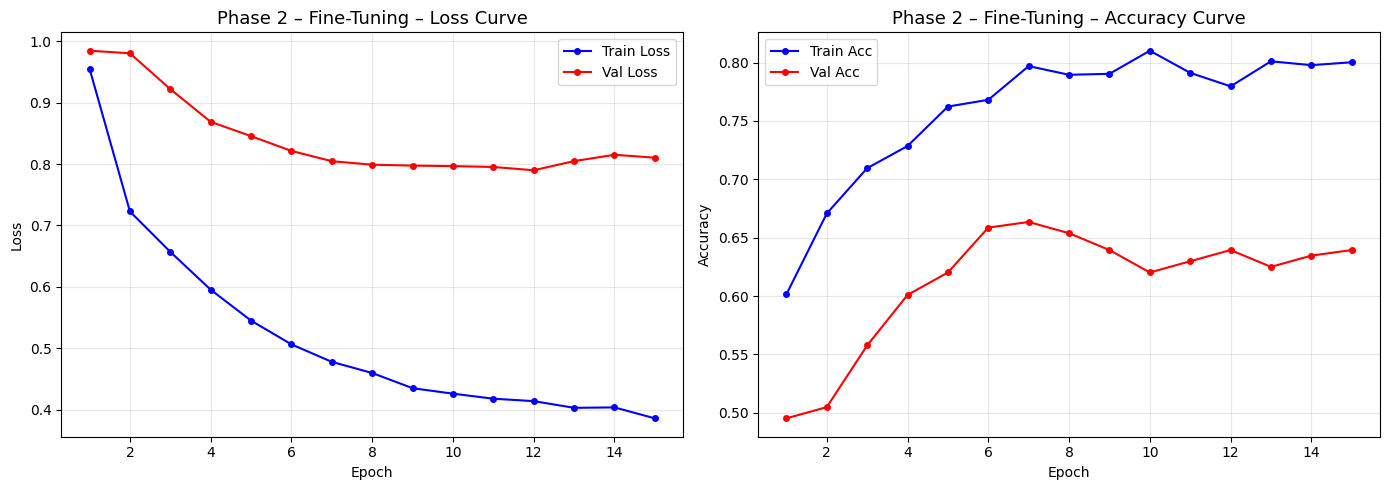


--- Phase 2 – Fine-Tuning: Classification Report ---
              precision    recall  f1-score   support

      benign       0.32      0.37      0.35        51
   malignant       0.83      0.90      0.86       148
      normal       0.27      0.16      0.20        50

    accuracy                           0.64       249
   macro avg       0.47      0.48      0.47       249
weighted avg       0.61      0.64      0.62       249



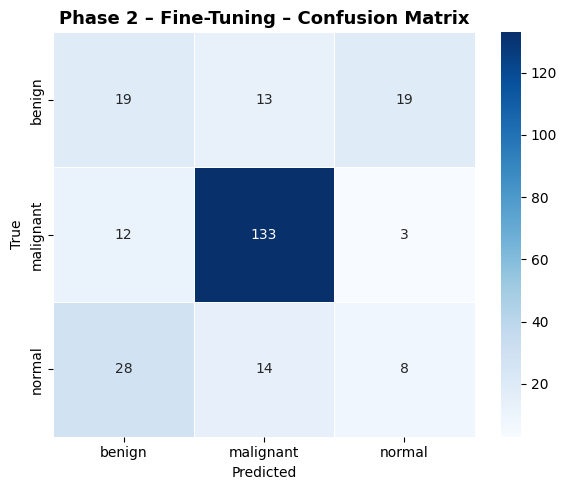

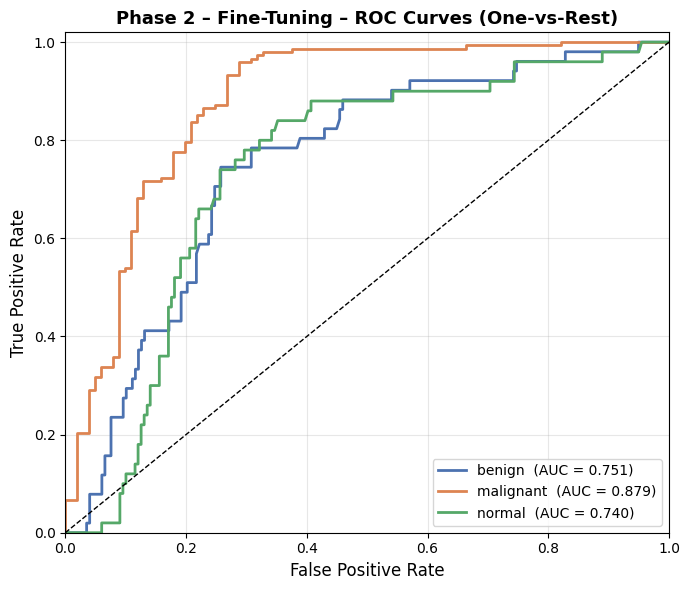

In [11]:
print("\n--- Phase 2: Fine-Tuning ---")

# Identify layer names for selective unfreezing
print("\nLast 40 base model layers:")
for i, layer in enumerate(base_model.layers[-40:]):
    print(f"  [{len(base_model.layers)-40+i:3d}] {layer.name:<45} trainable={layer.trainable}")

# Unfreeze from conv5_block1 onwards (last ~30 layers)
UNFREEZE_FROM = 'conv5_block1_1_conv'
unfreeze = False
for layer in base_model.layers:
    if layer.name == UNFREEZE_FROM:
        unfreeze = True
    layer.trainable = unfreeze

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"\nUnfrozen layers in base: {trainable_count} / {len(base_model.layers)}")

# Recompile with a very small learning rate to avoid catastrophic forgetting
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_ckpt_p2 = callbacks.ModelCheckpoint(
    os.path.join(project_path, 'best_model_phase2.h5'),
    monitor='val_accuracy', save_best_only=True, verbose=1)
cb_early2  = callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                      restore_best_weights=True, verbose=1)
cb_reduce2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                          patience=15, min_lr=1e-8, verbose=1)

history_p2 = model.fit(
    train_ds_pp, validation_data=val_ds_pp,
    epochs=EPOCHS_FT,
    callbacks=[cb_early2, cb_reduce2, cb_ckpt_p2],
    verbose=1
)

# Evaluate Phase 2
plot_training_curves(history_p2, "Phase 2 – Fine-Tuning")
y_true_p2, y_pred_p2, y_prob_p2 = full_evaluation(
    model, test_ds_pp, class_names, "Phase 2 – Fine-Tuning")


--- Combined Training Curves (Phase 1 & 2) ---


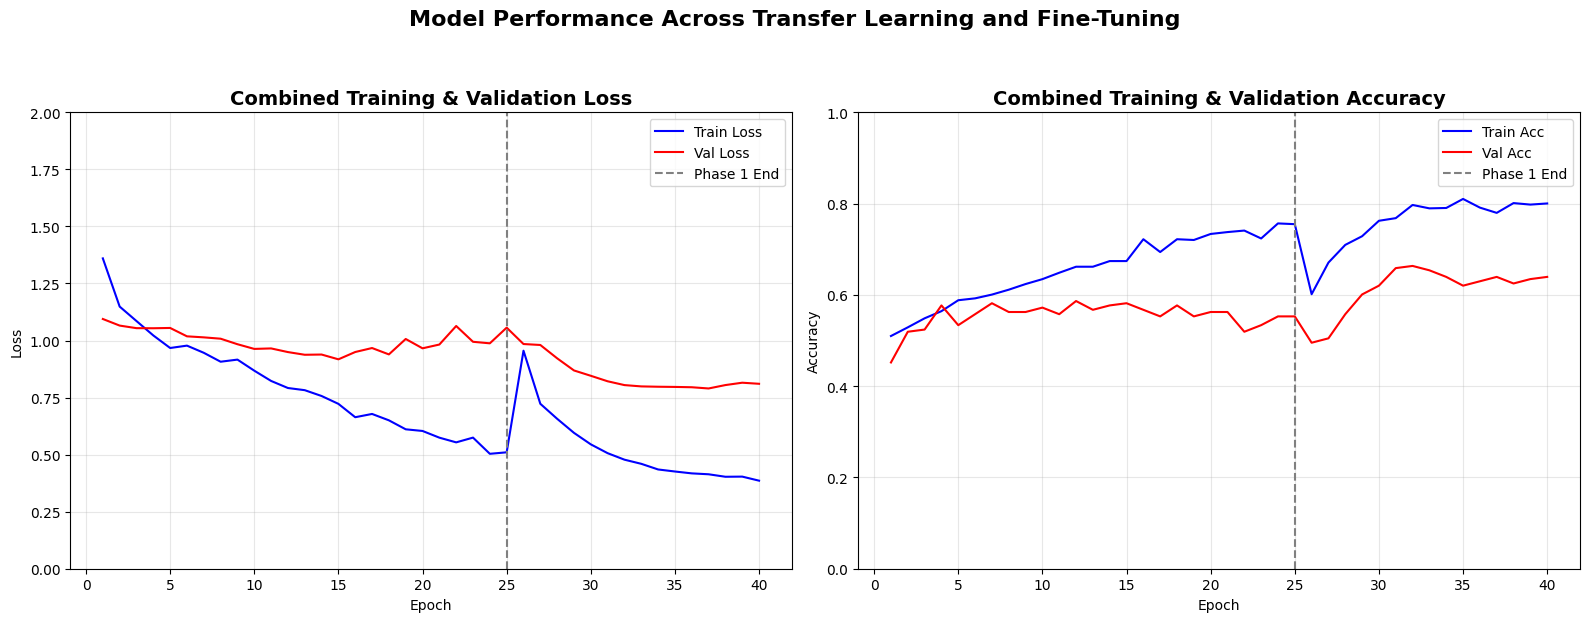

In [12]:
print("\n--- Combined Training Curves (Phase 1 & 2) ---")

# Combine histories
combined_history = {}
for metric in ['loss', 'val_loss', 'accuracy', 'val_accuracy']:
    combined_history[metric] = history_p1.history[metric] + history_p2.history[metric]

epochs_p1 = len(history_p1.history['loss'])
ep = range(1, len(combined_history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Combined Loss Curve ---
axes[0].plot(ep, combined_history['loss'], 'b-', label='Train Loss',  linewidth=1.5)
axes[0].plot(ep, combined_history['val_loss'], 'r-', label='Val Loss',    linewidth=1.5)
axes[0].axvline(x=epochs_p1, color='gray', linestyle='--', label='Phase 1 End')
axes[0].set_title('Combined Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_ylim([0.00, 2]) # Set y-axis limit for loss
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- Combined Accuracy Curve ---
axes[1].plot(ep, combined_history['accuracy'], 'b-', label='Train Acc', linewidth=1.5)
axes[1].plot(ep, combined_history['val_accuracy'], 'r-', label='Val Acc',   linewidth=1.5)
axes[1].axvline(x=epochs_p1, color='gray', linestyle='--', label='Phase 1 End')
axes[1].set_title('Combined Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.00, 1.00]) # Set y-axis limit for accuracy
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model Performance Across Transfer Learning and Fine-Tuning', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(project_path, 'combined_curves_phase1_phase2.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## GRAD-CAM VISUALIZATION (on Prewitt-preprocessed test images)

In [13]:
#   Col 1 – Prewitt test image used for inference (what the model actually saw)
#   Col 2 – Grad-CAM attention heatmap
#   Col 3 – Heatmap overlaid on Prewitt image

In [14]:
# ResNet50 last conv output layer
GRAD_CAM_LAYER = 'conv5_block3_out'
layer_names    = [l.name for l in base_model.layers]
assert GRAD_CAM_LAYER in layer_names, \
    f"Layer '{GRAD_CAM_LAYER}' not found. Last 5: {layer_names[-5:]}"

grad_model = Model(
    inputs  = base_model.input,
    outputs = [base_model.get_layer(GRAD_CAM_LAYER).output,
               base_model.output]
)

# Collect top-of-model layers (after the base)
base_output_layer_name = base_model.layers[-1].name
top_layers = []
found_base = False
for lyr in model.layers:
    if found_base:
        top_layers.append(lyr)
    if lyr.name == base_output_layer_name:
        found_base = True


def make_gradcam_heatmap(img_array, grad_model, top_model_layers, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array)
        tape.watch(conv_outputs)
        x = base_out
        for lyr in top_model_layers:
            x = lyr(x)
        class_probs = x
        if pred_index is None:
            pred_index = tf.argmax(class_probs[0])
        class_channel = class_probs[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img_rgb, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(
        cv2.resize(heatmap_uint8, (img_rgb.shape[1], img_rgb.shape[0])), colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlaid = np.uint8(alpha * heatmap_color + (1 - alpha) * img_rgb)
    return overlaid, heatmap_color


--- Generating Grad-CAM Visualizations (ResNet50 + Prewitt) ---


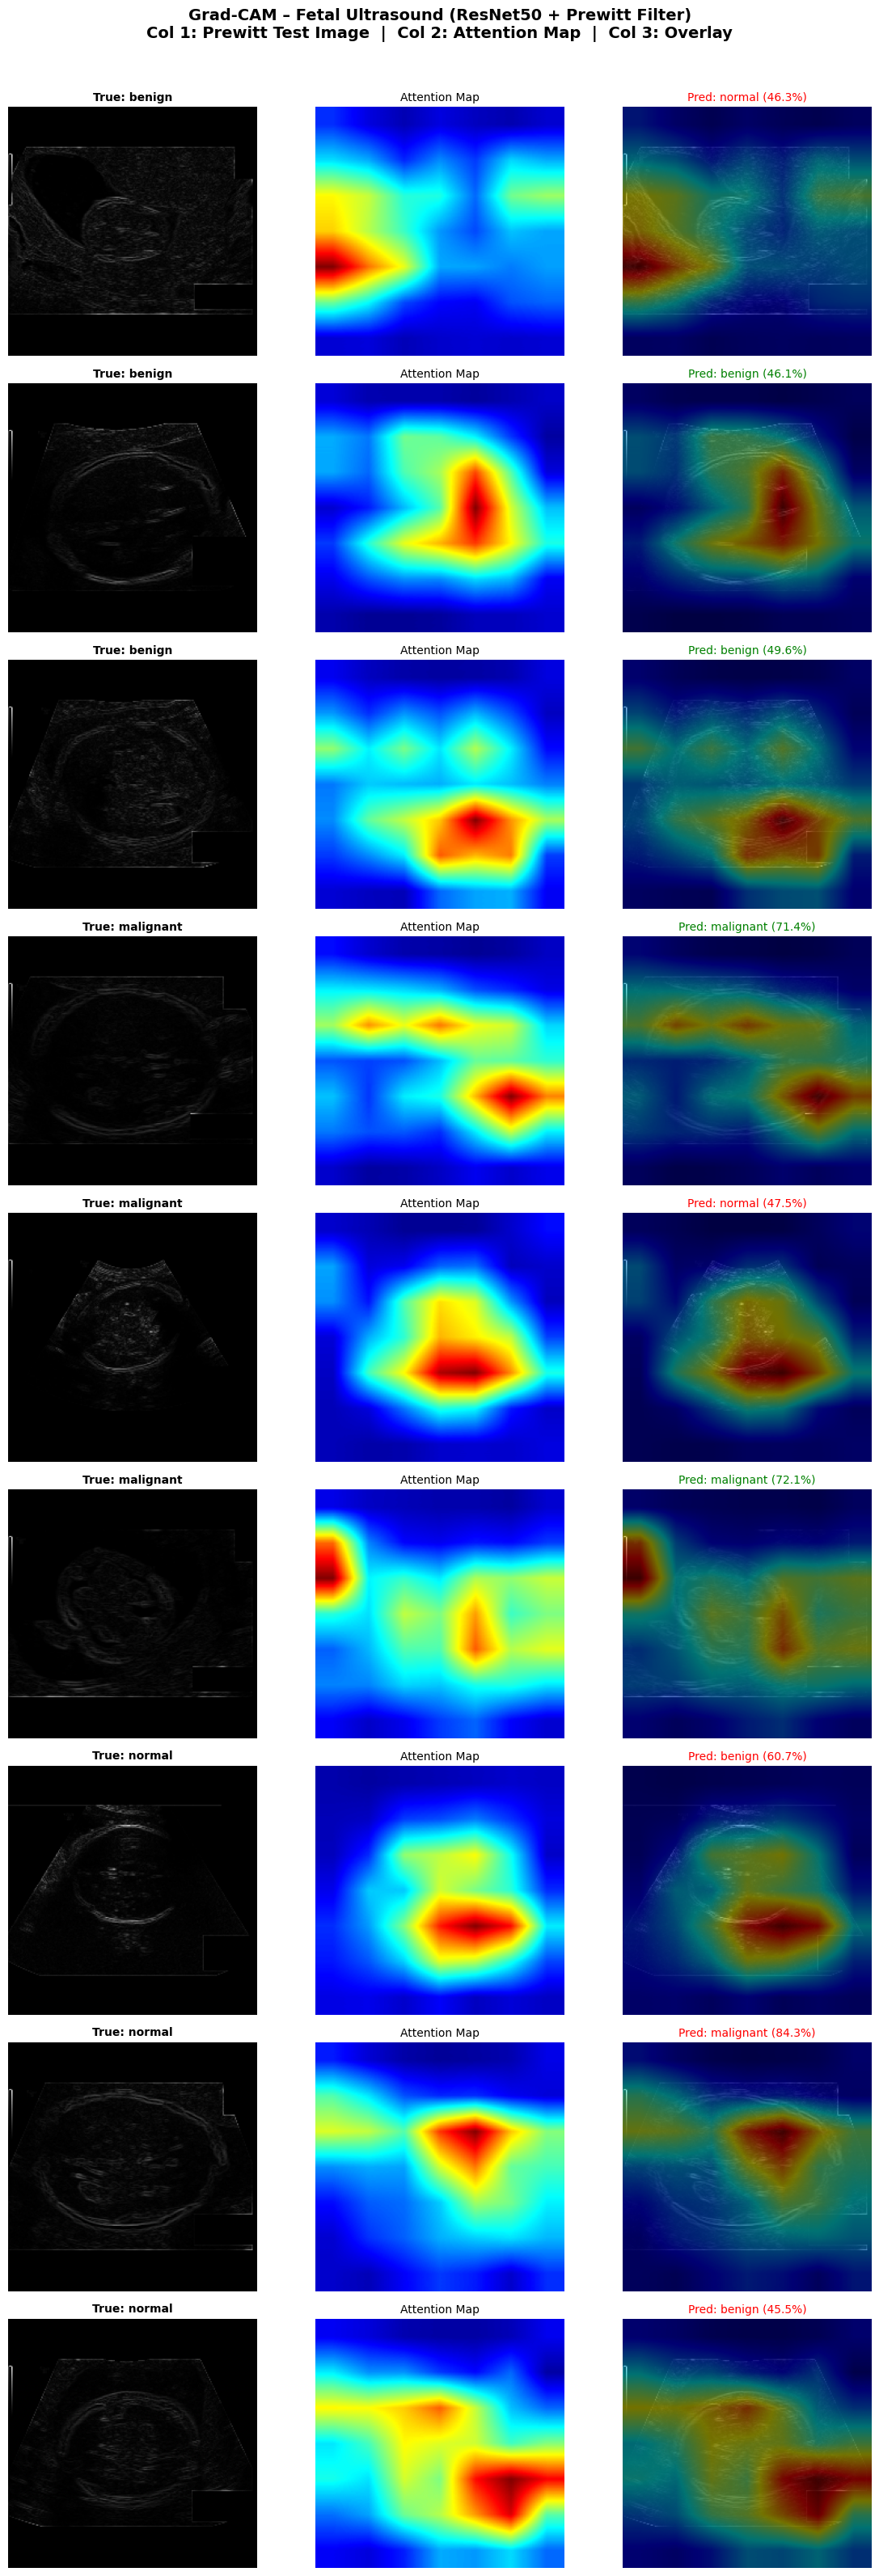

Grad-CAM figure saved.


In [15]:
# Select 3 random Prewitt test images per class
random.seed(SEED)
grad_cam_samples = {}
for cls in class_names:
    cls_dir  = os.path.join(prep_prewitt_dir, 'test', cls)
    all_imgs = [p for p in glob.glob(os.path.join(cls_dir, '*.*'))
                if 'Annotation' not in os.path.basename(p)]
    grad_cam_samples[cls] = random.sample(all_imgs, min(3, len(all_imgs)))

print("\n--- Generating Grad-CAM Visualizations (ResNet50 + Prewitt) ---")

nrows = sum(len(v) for v in grad_cam_samples.values())
fig, axes = plt.subplots(nrows, 3, figsize=(12, nrows * 3.5))
fig.suptitle(
    'Grad-CAM – Fetal Ultrasound (ResNet50 + Prewitt Filter)\n'
    'Col 1: Prewitt Test Image  |  Col 2: Attention Map  |  Col 3: Overlay',
    fontsize=14, fontweight='bold', y=1.01)

row = 0
for cls in class_names:
    for img_path in grad_cam_samples[cls]:

        # 1. Load Prewitt-preprocessed image (grayscale → RGB)
        prewitt_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        prewitt_rs   = cv2.resize(prewitt_gray, IMG_SIZE)
        prewitt_rgb  = cv2.cvtColor(prewitt_rs, cv2.COLOR_GRAY2RGB)   # (224,224,3)

        # 2. Preprocess for ResNet50
        img_array = preprocess_input(
            np.expand_dims(prewitt_rgb.astype(np.float32), 0))

        # 3. Predict & Grad-CAM
        pred_probs = model.predict(img_array, verbose=0)[0]
        pred_class = np.argmax(pred_probs)
        pred_label = class_names[pred_class]
        confidence = pred_probs[pred_class]

        heatmap = make_gradcam_heatmap(img_array, grad_model, top_layers, pred_class)
        overlaid, heatmap_colored = overlay_heatmap(prewitt_rgb, heatmap)

        # 4. Plot
        ax_raw = axes[row, 0]
        ax_hm  = axes[row, 1]
        ax_ov  = axes[row, 2]

        ax_raw.imshow(prewitt_rgb, cmap='gray')
        ax_raw.set_title(f'True: {cls}', fontsize=10, fontweight='bold')
        ax_raw.axis('off')

        ax_hm.imshow(heatmap_colored)
        ax_hm.set_title('Attention Map', fontsize=10)
        ax_hm.axis('off')

        ax_ov.imshow(overlaid)
        ax_ov.set_title(
            f'Pred: {pred_label} ({confidence:.1%})', fontsize=10,
            color='green' if pred_label == cls else 'red')
        ax_ov.axis('off')

        row += 1

plt.tight_layout()
plt.savefig(os.path.join(project_path, 'gradcam_resnet50_prewitt.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM figure saved.")

## SAVE FINAL MODEL

In [16]:
final_model_path = os.path.join(project_path, 'resnet50_prewitt_fetus_final.h5')
model.save(final_model_path)
print(f"\nFinal model saved to: {final_model_path}")

print("\n=== All done! ===")
print(f"Outputs saved in: {project_path}")
print("  • preprocessing_prewitt/       ← Prewitt images (train/val/test × 3 classes)")
print("  • best_model_phase1.h5")
print("  • best_model_phase2.h5")
print("  • resnet50_prewitt_fetus_final.h5")
print("  • curves_Phase_1_*_prewitt.png / curves_Phase_2_*_prewitt.png")
print("  • cm_Phase_1_*_prewitt.png    / cm_Phase_2_*_prewitt.png")
print("  • roc_Phase_1_*_prewitt.png   / roc_Phase_2_*_prewitt.png")
print("  • gradcam_resnet50_prewitt.png")


Final model saved to: /content/drive/MyDrive/CSE420/resnet50_prewitt_fetus_final.h5

=== All done! ===
Outputs saved in: /content/drive/MyDrive/CSE420
  • preprocessing_prewitt/       ← Prewitt images (train/val/test × 3 classes)
  • best_model_phase1.h5
  • best_model_phase2.h5
  • resnet50_prewitt_fetus_final.h5
  • curves_Phase_1_*_prewitt.png / curves_Phase_2_*_prewitt.png
  • cm_Phase_1_*_prewitt.png    / cm_Phase_2_*_prewitt.png
  • roc_Phase_1_*_prewitt.png   / roc_Phase_2_*_prewitt.png
  • gradcam_resnet50_prewitt.png
